# COMP5310 — Stage 2: Modelling and Evaluation Notebook

**Group:** Lab_05_Group_10  
**Dataset:** Hotel Bookings (Dataset C)  
**Task:** Binary classification — predict `is_canceled` from booking-time features.

## Directions to run
1. Install Python 3.10 or later.
2. Install dependencies: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`.
3. Run the **data cleaning notebook** first to generate `hotel_cleaned_stage2.csv`.
4. Place `hotel_cleaned_stage2.csv` in the same folder as this notebook.
5. Run all cells top-to-bottom.

## Notebook structure
1. Setup — imports, load data, target/feature definition
2. Preprocessing pipeline (shared across all supervised models)
3. Train/test split
4. **Model 1: Logistic Regression** (supervised, linear)
5. **Model 2: Random Forest** (supervised, ensemble)
6. **Model 3: K-Means** (unsupervised, clustering)
7. Comparative analysis
8. Discussion

---
# 1. Setup


## 1.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, silhouette_score)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Setup complete. Random state:", RANDOM_STATE)


Setup complete. Random state: 42


## 1.2 Load cleaned data

In [2]:
df = pd.read_csv('hotel_cleaned_stage2.csv')
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['is_canceled'].value_counts(normalize=True).round(4))
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (119793, 34)

Target distribution:
is_canceled
0    0.6293
1    0.3707
Name: proportion, dtype: float64

First 3 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,has_special_request,is_summer_arrival,prev_cancel_rate
0,City Hotel,1,29,2016,February,6,5,6,14,1,...,0,Transient,70.91,0,0,20,1.0,0,0,0.0
1,Resort Hotel,0,312,2017,March,10,5,2,5,2,...,0,Transient-Party,56.00,0,0,7,2.0,0,0,0.0
2,Resort Hotel,0,19,2016,February,9,27,0,1,2,...,0,Transient,0.00,0,0,1,2.0,0,0,0.0


## 1.3 Define target and features

**Target:** `is_canceled`

**Numerical features:** `lead_time`, `total_of_special_requests`, `booking_changes`, `previous_cancellations`, `previous_bookings_not_canceled`, `adults`, `children`, `babies`, `adr`, `stays_in_weekend_nights`, `stays_in_week_nights`, `days_in_waiting_list`, `required_car_parking_spaces`, `is_repeated_guest`, `total_nights`, `total_guests`, `has_special_request`, `is_summer_arrival`, `prev_cancel_rate`

**Categorical features:** `hotel`, `deposit_type`, `market_segment`, `customer_type`, `meal`, `distribution_channel`, `arrival_date_month`, `reserved_room_type`

**Excluded (high cardinality / leakage / redundant):** `country`, `agent`, `assigned_room_type`, `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month`

In [3]:
TARGET = 'is_canceled'

NUMERICAL_FEATURES = [
    # Original numerical features (14)
    'lead_time', 'total_of_special_requests', 'booking_changes',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'adults', 'children', 'babies', 'adr',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'days_in_waiting_list', 'required_car_parking_spaces',
    'is_repeated_guest',
    # Engineered features (5)
    'total_nights', 'total_guests', 'has_special_request',
    'is_summer_arrival', 'prev_cancel_rate'
]

CATEGORICAL_FEATURES = [
    'hotel', 'deposit_type', 'market_segment', 'customer_type',
    'meal', 'distribution_channel', 'arrival_date_month', 'reserved_room_type'
]

EXCLUDED_FEATURES = [
    'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'country', 'assigned_room_type', 'agent'
]

# Verify all selected columns exist in the cleaned dataset
missing = [c for c in NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET] if c not in df.columns]
assert not missing, f"Columns missing from CSV: {missing}"

X = df[NUMERICAL_FEATURES + CATEGORICAL_FEATURES].copy()
y = df[TARGET].copy()

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"  Numerical features:   {len(NUMERICAL_FEATURES)}")
print(f"  Categorical features: {len(CATEGORICAL_FEATURES)}")

X shape: (119793, 27), y shape: (119793,)
  Numerical features:   19
  Categorical features: 8


---
# 2. Preprocessing Pipeline


Build a `ColumnTransformer` that:
- Standardises numerical features (needed for LR + K-Means)
- One-hot encodes categorical features

Tree-based models (Random Forest) don't strictly need scaling but it doesn't hurt. The same preprocessor is reused across all supervised models for a fair comparison.

In [4]:
# Quick sanity check — transform once using a clone so the main
# preprocessor remains unfitted until it is inside a train/CV Pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

X_check = clone(preprocessor).fit_transform(X)
print(f"After preprocessing: {X.shape[1]} columns -> {X_check.shape[1]} columns")
print(f"(numerical scaled + categorical one-hot encoded)")
del X_check  # don't keep this — will refit inside Pipelines


After preprocessing: 27 columns -> 64 columns
(numerical scaled + categorical one-hot encoded)


### Helper: extract feature names after preprocessing

The preprocessor expands categorical features via one-hot encoding, so the column names change. Use the helper below whenever you need feature names that match the rows of `coef_` / `feature_importances_`.

In [5]:
def get_feature_names_after_preprocess(fitted_preprocessor):
    """Return the list of feature names produced by the fitted ColumnTransformer.

    Order: numerical features first (kept as-is), then one-hot encoded categorical features.
    """
    num_names = NUMERICAL_FEATURES
    cat_names = list(
        fitted_preprocessor.named_transformers_['cat']
        .get_feature_names_out(CATEGORICAL_FEATURES)
    )
    return num_names + cat_names

# Quick demo using a clone, again avoiding any fitted state on the main preprocessor
demo_pre = clone(preprocessor).fit(X)
demo_names = get_feature_names_after_preprocess(demo_pre)
print(f"Total features after preprocessing: {len(demo_names)}")
print(f"First 5: {demo_names[:5]}")
print(f"Last 5:  {demo_names[-5:]}")


Total features after preprocessing: 64
First 5: ['lead_time', 'total_of_special_requests', 'booking_changes', 'previous_cancellations', 'previous_bookings_not_canceled']
Last 5:  ['reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 'reserved_room_type_H', 'reserved_room_type_L']


---
# 3. Train/Test Split

Stratified 80/20 split to preserve the 37% positive class ratio in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y  # preserve the 37%/63% class ratio in both splits
)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"\nTrain class balance:")
print((y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print(f"Test  class balance:")
print((y_test.value_counts(normalize=True) * 100).round(2).to_dict())

Train set: 95834 rows | Test set: 23959 rows

Train class balance:
{0: 62.93, 1: 37.07}
Test  class balance:
{0: 62.93, 1: 37.07}


---
# 4. Model 1: Logistic Regression


Why this model: linear, interpretable baseline. Coefficients tell us the direction and magnitude of each feature's effect on cancellation probability.

**Hyperparameters to tune:**
- `C` (inverse regularisation strength): [0.01, 0.1, 1, 10]
- `penalty`: ['l1', 'l2']
- `solver`: 'liblinear' (supports both penalties)

## 4.1 Train with GridSearchCV

In [7]:
# 1. Build the Pipeline
lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, 
                              random_state=RANDOM_STATE, 
                              solver='liblinear'))
])

# 2. Define the parameter grid
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2']
}

# 3. Setup GridSearchCV
# Note: Using StratifiedKFold as requested for cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the model
print("Starting GridSearchCV for Logistic Regression...")
lr_search.fit(X_train, y_train)

# 5. & 6. Printing results
print("\n--- Logistic Regression Grid Search Results ---")
print(f"Best Parameters: {lr_search.best_params_}")
print(f"Best ROC-AUC Score: {lr_search.best_score_:.4f}")


Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- Logistic Regression Grid Search Results ---
Best Parameters: {'lr__C': 1, 'lr__penalty': 'l1'}
Best ROC-AUC Score: 0.8545


## 4.2 Evaluate on test set

In [8]:
# 1. Generate predictions for the test set
y_pred_lr = lr_search.predict(X_test)

# 2. Get probability estimates for the positive class (is_canceled = 1)
y_proba_lr = lr_search.predict_proba(X_test)[:, 1]

# 3. Compute metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

# 4. Print results
print("--- Logistic Regression Test Set Evaluation ---")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"ROC-AUC Score: {roc_auc:.4f}")

# 5. Save metrics to a dictionary
lr_results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'roc_auc': roc_auc
}

# Display the dictionary to confirm
print("\nFinal Metrics Dictionary:")
print(lr_results)

--- Logistic Regression Test Set Evaluation ---

Confusion Matrix:
[[13921  1156]
 [ 3508  5374]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86     15077
           1       0.82      0.61      0.70      8882

    accuracy                           0.81     23959
   macro avg       0.81      0.76      0.78     23959
weighted avg       0.81      0.81      0.80     23959

ROC-AUC Score: 0.8510

Final Metrics Dictionary:
{'accuracy': 0.8053341124420885, 'precision': 0.8229709035222053, 'recall': 0.6050439090294979, 'f1': 0.6973786659745653, 'roc_auc': 0.850952511924937}


## 4.3 Coefficient analysis

Top positive coefficients = features that increase cancellation probability.  
Top negative coefficients = features that decrease it.

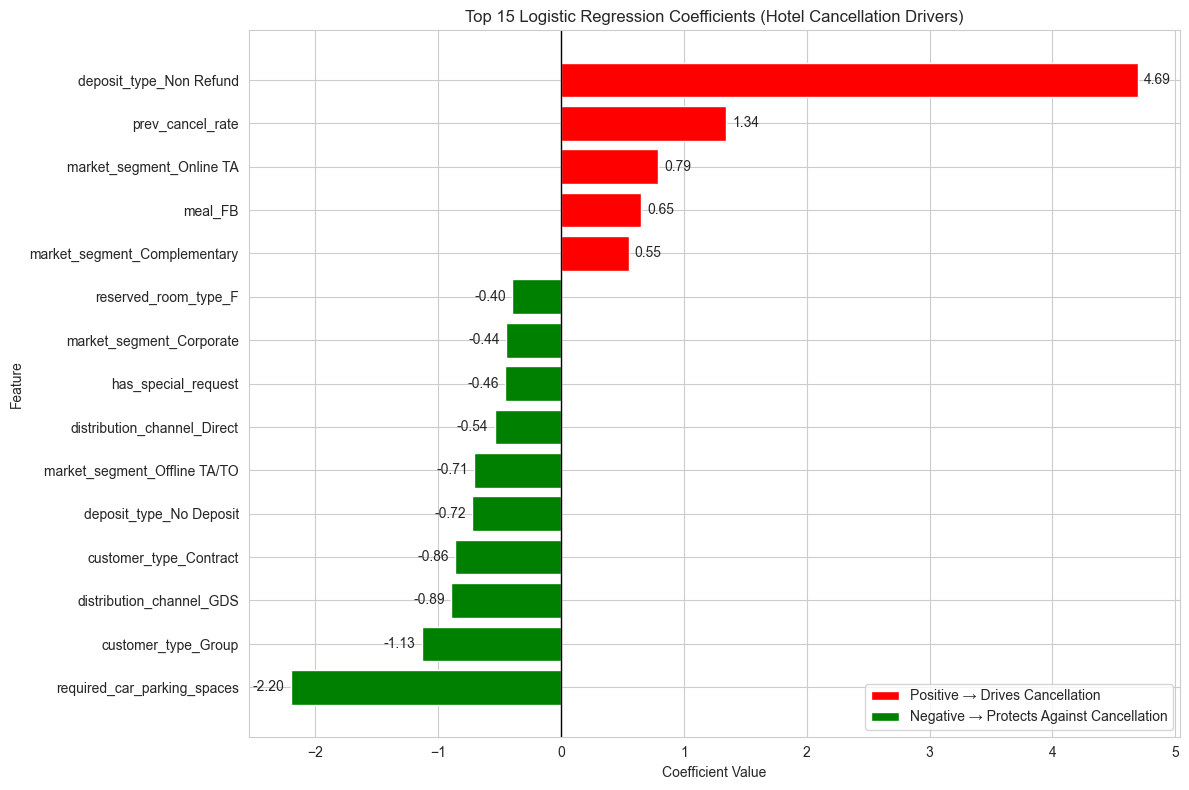

In [9]:
# 1. Get fitted logistic regression model
fitted_lr = lr_search.best_estimator_.named_steps['lr']

# 2. Get fitted preprocessing pipeline + transformed feature names
fitted_pre = lr_search.best_estimator_.named_steps['preprocess']
feature_names = get_feature_names_after_preprocess(fitted_pre)

# 3. Build coefficient dataframe
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': fitted_lr.coef_[0]
})

# 4. Sort by absolute importance and keep top 15
top_coef = (
    coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
           .head(15)
           .sort_values('coefficient')   # for cleaner horizontal plotting
)

# 5. Plot horizontal bar chart
plt.figure(figsize=(12, 8))

colors = ['red' if coef > 0 else 'green' for coef in top_coef['coefficient']]

plt.barh(
    top_coef['feature'],
    top_coef['coefficient'],
    color=colors
)

plt.axvline(0, color='black', linewidth=1)

plt.title('Top 15 Logistic Regression Coefficients (Hotel Cancellation Drivers)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

# Optional legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Positive → Drives Cancellation'),
    Patch(facecolor='green', label='Negative → Protects Against Cancellation')
]
plt.legend(handles=legend_elements)
for i, v in enumerate(top_coef['coefficient']):
    plt.text(v + (0.05 if v > 0 else -0.05), i, f'{v:.2f}',
             va='center', ha='left' if v > 0 else 'right')
plt.tight_layout()
plt.show()

---
# 5. Model 2: Random Forest

Why this model: non-linear ensemble that captures feature interactions. Provides feature importance directly.

**Hyperparameters to tune:**
- `n_estimators`: [100, 200]
- `max_depth`: [10, 20, None]
- `min_samples_split`: [2, 10]
- `class_weight`: [None, 'balanced']

## 5.1 Train with GridSearchCV

In [10]:
# 1. Build Pipeline
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# 2. Parameter Grid
rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 10],
    'rf__class_weight': [None, 'balanced']
}

# 3. Cross-validation strategy
rf_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# GridSearchCV
rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=rf_cv,
    n_jobs=-1,
    verbose=2
)

# 4. Fit on training data
rf_search.fit(X_train, y_train)

# 5. Print best parameters and best score
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV ROC-AUC Score:")
print(rf_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  26.6s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  27.2s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  27.8s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  28.0s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=100; total time=  28.1s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=200; total time=  43.8s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=200; total time=  44.0s
[CV] END rf__class_weight=None, rf__max_depth=10, rf__min_samples_split=2, rf__n_estimators=200; total time=  43.9s
[CV] END r

## 5.2 Evaluate on test set

In [11]:
# 1. Predictions
y_pred_rf = rf_search.predict(X_test)

# 2. Predicted probabilities
y_proba_rf = rf_search.predict_proba(X_test)[:, 1]

# 3. Compute metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

# 4. Print evaluation details
print("Random Forest Test Performance:")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 5. Save metrics to dictionary
rf_results = {
    'accuracy': rf_accuracy,
    'precision': rf_precision,
    'recall': rf_recall,
    'f1': rf_f1,
    'roc_auc': rf_roc_auc
}

print("\nSaved Results Dictionary:")
print(rf_results)

Random Forest Test Performance:
Accuracy : 0.8537
Precision: 0.8231
Recall   : 0.7711
F1 Score : 0.7963
ROC-AUC  : 0.9251

Confusion Matrix:
[[13605  1472]
 [ 2033  6849]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89     15077
           1       0.82      0.77      0.80      8882

    accuracy                           0.85     23959
   macro avg       0.85      0.84      0.84     23959
weighted avg       0.85      0.85      0.85     23959


Saved Results Dictionary:
{'accuracy': 0.8537084185483534, 'precision': 0.8230981853142652, 'recall': 0.77111011033551, 'f1': 0.7962564668953089, 'roc_auc': 0.9250835577847422}


## 5.3 Feature importance

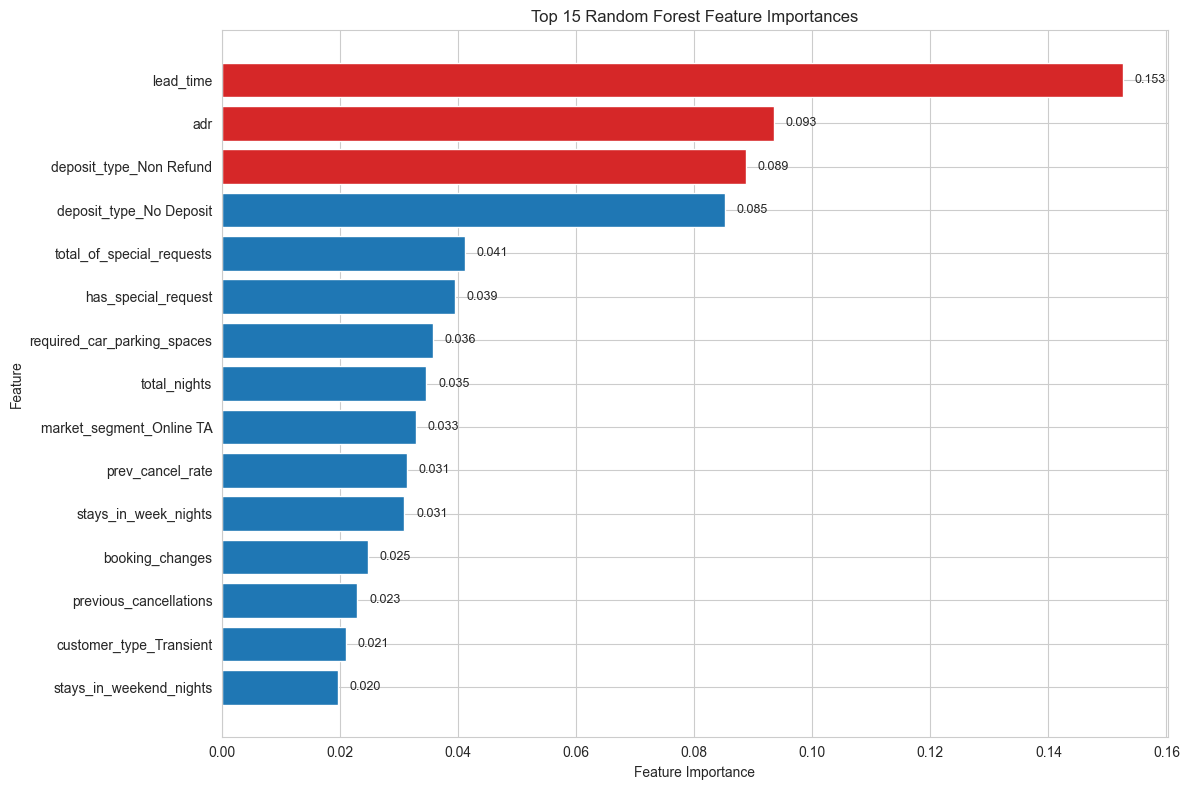

In [12]:
# 1. Get fitted Random Forest model
fitted_rf = rf_search.best_estimator_.named_steps['rf']

# 2. Get fitted preprocessor + transformed feature names
fitted_pre = rf_search.best_estimator_.named_steps['preprocess']
feature_names = get_feature_names_after_preprocess(fitted_pre)

# 3. Build importance dataframe
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': fitted_rf.feature_importances_
})

# 4. Sort descending and keep top 15
top_imp = (
    imp_df.sort_values('importance', ascending=False)
          .head(15)
          .sort_values('importance')   # cleaner horizontal chart
)

# 5. Plot horizontal bar chart
plt.figure(figsize=(12, 8))

colors = ['#1f77b4'] * len(top_imp)
colors[-3:] = ['#d62728'] * 3

plt.barh(top_imp['feature'], top_imp['importance'], color=colors)
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
for i, v in enumerate(top_imp['importance']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


---
# 6. Model 3: K-Means Clustering

Why this model: unsupervised — finds natural groupings of bookings without using `is_canceled`. We then check whether clusters happen to align with cancellation behaviour, giving us a customer segmentation view.

**Approach:**
1. Use the same preprocessor (scaled numerical + one-hot categorical)
2. Use the elbow method + silhouette score to choose `k`
3. Profile each cluster (sizes, mean feature values, cancellation rate)

## 6.1 Prepare data for clustering

Apply the preprocessor (without `is_canceled`) to get a numeric matrix suitable for K-Means.

In [13]:
# K-Means is unsupervised, so we use the FULL feature matrix X
# (we don't need a train/test split — there's no target to predict).
# We refit a separate preprocessor here to keep the supervised pipeline isolated.

preprocessor_km = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         CATEGORICAL_FEATURES)
    ]
)

X_for_clustering = preprocessor_km.fit_transform(X)
print(f"Shape ready for K-Means: {X_for_clustering.shape}")
print(f"Numerical features mean (should be ~0): {X_for_clustering[:, :len(NUMERICAL_FEATURES)].mean():.4f}")
print(f"Numerical features std  (should be ~1): {X_for_clustering[:, :len(NUMERICAL_FEATURES)].std():.4f}")

Shape ready for K-Means: (119793, 64)
Numerical features mean (should be ~0): -0.0000
Numerical features std  (should be ~1): 1.0000


## 6.2 Choose k (elbow + silhouette)

Sweeping k=2..8:
  k=2: inertia= 2,477,661  silhouette=0.1126
  k=3: inertia= 2,328,618  silhouette=0.1071
  k=4: inertia= 2,182,971  silhouette=0.1253
  k=5: inertia= 2,057,069  silhouette=0.1326
  k=6: inertia= 1,921,186  silhouette=0.1414
  k=7: inertia= 1,832,813  silhouette=0.1421
  k=8: inertia= 1,728,885  silhouette=0.1454


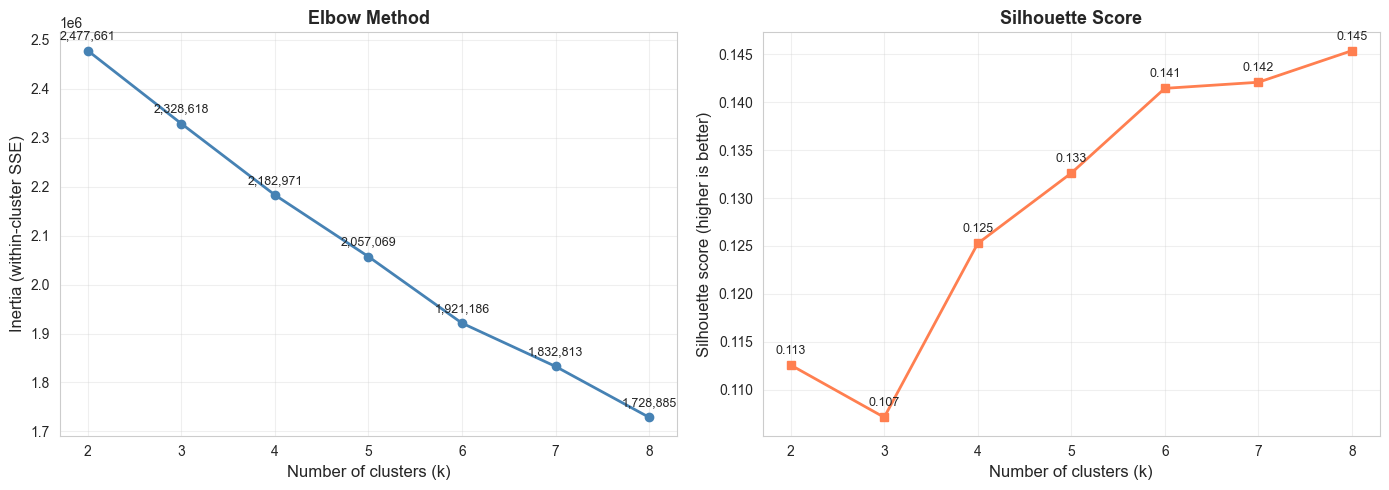


Chosen k = 4 (favouring interpretability; silhouette = 0.1253, close to the maximum at k=8)


In [14]:
# Sweep k from 2 to 8 — record both inertia (within-cluster SSE) and
# silhouette score. Silhouette is computed on a sample for speed (it's O(n^2)).

K_RANGE = list(range(2, 9))
SILHOUETTE_SAMPLE_SIZE = 5000

inertias = []
silhouettes = []

# Random sample for silhouette calculation
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_for_clustering), SILHOUETTE_SAMPLE_SIZE, replace=False)
X_sample = X_for_clustering[sample_idx]

print("Sweeping k=2..8:")
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_for_clustering)
    inertias.append(km.inertia_)

    # silhouette on the sample
    labels_sample = km.predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample)
    silhouettes.append(sil)
    print(f"  k={k}: inertia={km.inertia_:>10,.0f}  silhouette={sil:.4f}")

# Plot elbow + silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias, marker='o', linewidth=2, color='steelblue')
axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (within-cluster SSE)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
for k, val in zip(K_RANGE, inertias):
    axes[0].annotate(f'{val:,.0f}', (k, val), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=9)

axes[1].plot(K_RANGE, silhouettes, marker='s', linewidth=2, color='coral')
axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette score (higher is better)', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
for k, val in zip(K_RANGE, silhouettes):
    axes[1].annotate(f'{val:.3f}', (k, val), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

# Decision: silhouette is roughly flat across k, so we choose based on
# interpretability. k=4 gives a clean four-segment story while still
# capturing the main structure visible in the elbow curve.
K_FINAL = 4
print(f"\nChosen k = {K_FINAL} (favouring interpretability; "
      f"silhouette = {silhouettes[K_RANGE.index(K_FINAL)]:.4f}, "
      f"close to the maximum at k={K_RANGE[np.argmax(silhouettes)]})")

## 6.3 Fit final K-Means

In [15]:
kmeans_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_for_clustering)

# Attach cluster labels to a copy of the original (un-encoded) df so we can
# read cluster characteristics in human-readable form (hotel name, deposit type, etc.)
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"K-Means fitted with k={K_FINAL}")
print(f"\nCluster sizes:")
print(df_clustered['cluster'].value_counts().sort_index())
print(f"Final inertia: {kmeans_final.inertia_:,.0f}")

K-Means fitted with k=4

Cluster sizes:
cluster
0    16220
1    56581
2    43203
3     3789
Name: count, dtype: int64
Final inertia: 2,182,971


## 6.4 Cluster profiles

For each cluster, report: size, cancellation rate, mean of key numerical features, mode of key categorical features.

Overall cancellation rate: 37.07%

Cluster summary:

          size  cancel_rate_%  lead_time  total_nights  total_guests     adr  total_of_special_requests  booking_changes  prev_cancel_rate         hotel deposit_type market_segment customer_type
cluster                                                                                                                                                                                           
0        16220          36.42     141.85          8.16          2.16  110.69                       0.60             0.34              0.01  Resort Hotel   No Deposit      Online TA     Transient
1        56581          48.73     118.09          2.58          1.74   89.16                       0.02             0.18              0.04    City Hotel   No Deposit         Groups     Transient
2        43203          24.00      83.68          2.90          2.24  121.30                       1.28             0.23              0.00    City Hotel   No Deposit  

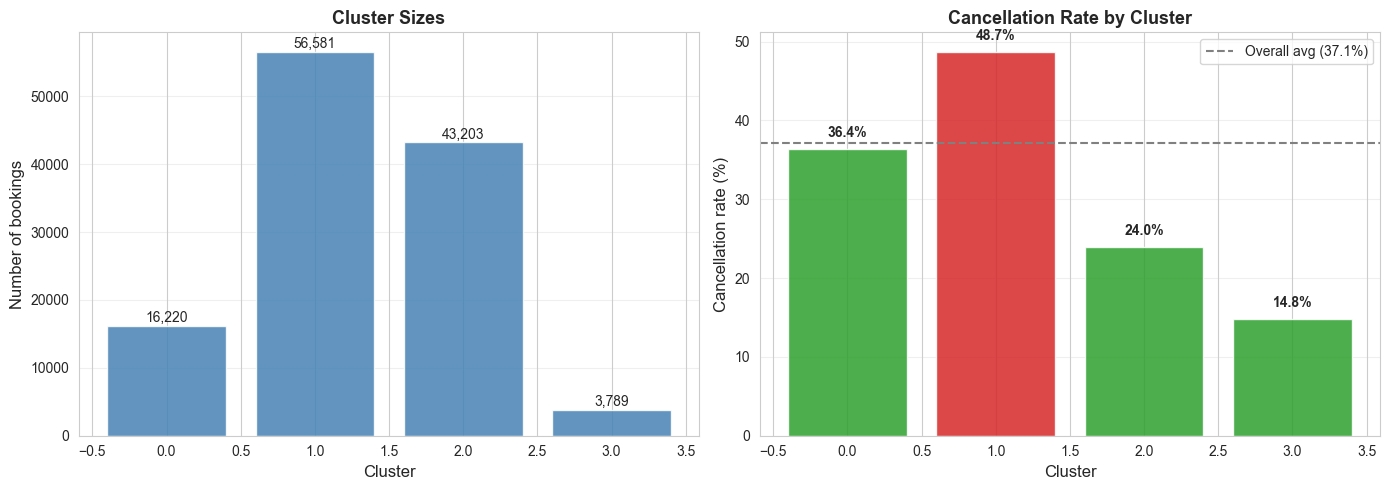

In [16]:
# Build cluster profile: size + cancellation rate + key numerical means + dominant categories.

num_profile_cols = [
    'lead_time', 'total_nights', 'total_guests', 'adr',
    'total_of_special_requests', 'booking_changes', 'prev_cancel_rate'
]
cat_profile_cols = ['hotel', 'deposit_type', 'market_segment', 'customer_type']

profile_num = df_clustered.groupby('cluster')[num_profile_cols].mean().round(2)
profile_cat = df_clustered.groupby('cluster')[cat_profile_cols].agg(
    lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'N/A'
)

cluster_size = df_clustered.groupby('cluster').size()
cancel_rate = (df_clustered.groupby('cluster')['is_canceled'].mean() * 100).round(2)
overall_rate = df_clustered['is_canceled'].mean() * 100

cluster_summary = pd.DataFrame({
    'size': cluster_size,
    'cancel_rate_%': cancel_rate
}).join(profile_num).join(profile_cat)

print(f"Overall cancellation rate: {overall_rate:.2f}%")
print(f"\nCluster summary:\n")
print(cluster_summary.to_string())

# Visualisation: cluster sizes and cancellation rates side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
axes[0].bar(cluster_size.index, cluster_size.values,
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Number of bookings', fontsize=12)
axes[0].set_title('Cluster Sizes', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in zip(cluster_size.index, cluster_size.values):
    axes[0].text(i, v + max(cluster_size) * 0.01, f'{v:,}',
                 ha='center', fontsize=10)

# Cancellation rate per cluster
colors = ['#2ca02c' if r < overall_rate else '#d62728' for r in cancel_rate.values]
axes[1].bar(cancel_rate.index, cancel_rate.values,
            color=colors, edgecolor='white', alpha=0.85)
axes[1].axhline(overall_rate, linestyle='--', color='gray',
                label=f'Overall avg ({overall_rate:.1f}%)')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Cancellation rate (%)', fontsize=12)
axes[1].set_title('Cancellation Rate by Cluster', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(loc='upper right')
for i, v in zip(cancel_rate.index, cancel_rate.values):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kmeans_cluster_profiles.png', dpi=100, bbox_inches='tight')
plt.show()

### 6.5 Cluster interpretation and business labels

To make the clusters meaningful for the report, we attach a qualitative business label to each cluster based on its profile. The cell below ranks clusters by cancellation rate so the riskiest segments are easy to spot.

In [17]:
# Sort clusters by cancellation rate (low → high) for clearer storytelling
sorted_summary = cluster_summary.sort_values('cancel_rate_%')

# Suggested business labels (these are interpretive, edit to match what you see in the data)
business_labels = {}
for cluster_id, row in sorted_summary.iterrows():
    rate = row['cancel_rate_%']
    hotel = row['hotel']
    segment = row['market_segment']
    cust = row['customer_type']

    if rate < 20:
        risk = "Low risk"
    elif rate < 35:
        risk = "Below-average risk"
    elif rate < 45:
        risk = "Above-average risk"
    else:
        risk = "High risk"

    manual_labels = {
    3: "Low risk: Corporate short-stay business travel",
    2: "Below-average risk: Online TA city leisure",
    0: "Above-average risk: Resort vacation long-stay",
    1: "High risk: Group bookings (events/conferences)"
}

print("Clusters ranked by cancellation rate (lowest → highest):\n")
for cluster_id, label in manual_labels.items():
    row = sorted_summary.loc[cluster_id]
    print(f"  Cluster {cluster_id} | size={row['size']:>6,} | "
          f"cancel={row['cancel_rate_%']:>5.1f}% | {label}")

print(f"\nOverall cancellation rate: {overall_rate:.2f}%")
print(f"Spread: {sorted_summary['cancel_rate_%'].max() - sorted_summary['cancel_rate_%'].min():.1f} percentage points "
      f"between best and worst cluster")

Clusters ranked by cancellation rate (lowest → highest):

  Cluster 3 | size= 3,789 | cancel= 14.8% | Low risk: Corporate short-stay business travel
  Cluster 2 | size=43,203 | cancel= 24.0% | Below-average risk: Online TA city leisure
  Cluster 0 | size=16,220 | cancel= 36.4% | Above-average risk: Resort vacation long-stay
  Cluster 1 | size=56,581 | cancel= 48.7% | High risk: Group bookings (events/conferences)

Overall cancellation rate: 37.07%
Spread: 33.9 percentage points between best and worst cluster


---
# 7. Comparative Analysis


Compare the three methods on metrics that make sense for each:
- LR vs RF: head-to-head on the same supervised task (Accuracy, Precision, Recall, F1, ROC-AUC)
- K-Means: insight-based comparison — what segments did it find that supervised models can't show?

## 7.1 Quantitative comparison (LR vs RF)

In [18]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Logistic Regression': lr_results,
    'Random Forest': rf_results
}).round(4)

# Display comparison
print("Model Performance Comparison:")
print(comparison)

Model Performance Comparison:
           Logistic Regression  Random Forest
accuracy                0.8053         0.8537
precision               0.8230         0.8231
recall                  0.6050         0.7711
f1                      0.6974         0.7963
roc_auc                 0.8510         0.9251


## 7.2 ROC curves on test set

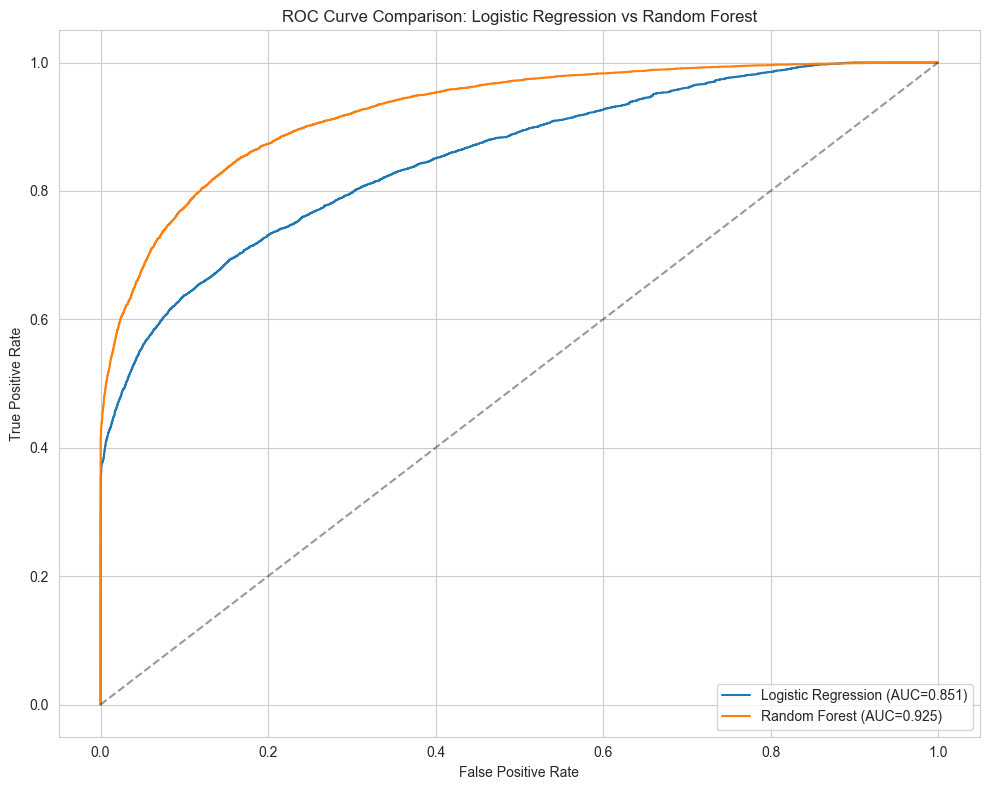

In [19]:
# 1. ROC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

# 2. ROC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

# Create plot
plt.figure(figsize=(10, 8))

# 3. Logistic Regression ROC
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC={lr_results["roc_auc"]:.3f})'
)

# 4. Random Forest ROC
plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC={rf_results["roc_auc"]:.3f})'
)

# 5. Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)

# 6. Labels and formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Logistic Regression vs Random Forest')
plt.legend(loc='lower right')

# Save figure
plt.savefig("lr_vs_rf_roc_curve.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 7.3 Confusion matrices side by side

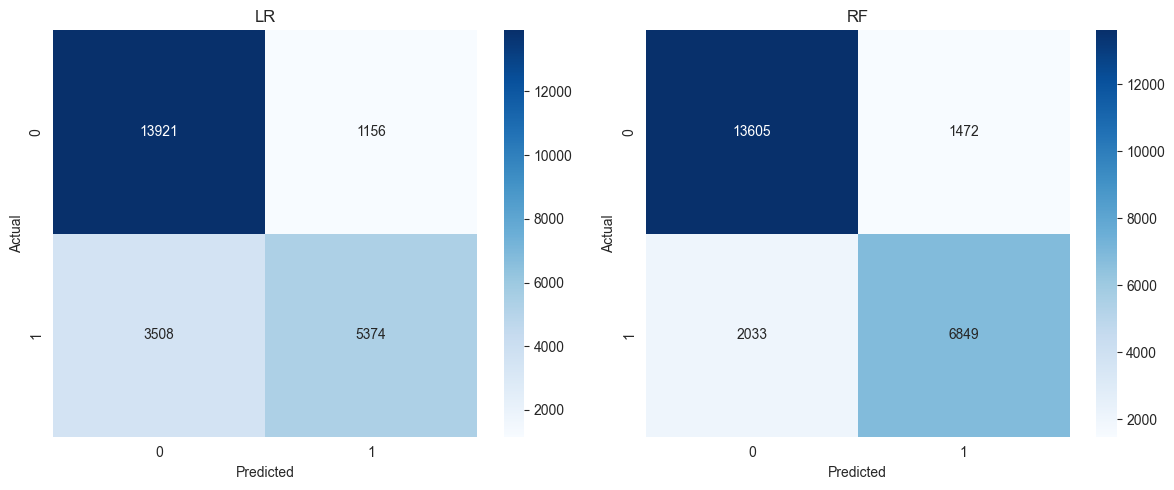

In [20]:
# 1. Create subplot layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. Loop through models
for ax, (name, y_pred) in zip(
    axes,
    [('LR', y_pred_lr), ('RF', y_pred_rf)]
):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# 3. Final formatting and save
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches='tight')

plt.show()

## 7.4 Insight comparison: K-Means vs supervised models

The supervised models and K-Means answer different but complementary questions. Logistic Regression and Random Forest predict whether an individual booking is likely to be cancelled, so they are most useful when the hotel needs a booking-level risk score for overbooking, pricing, or intervention decisions. K-Means does not optimise prediction accuracy and does not use the target label during fitting; instead, it groups bookings with similar reservation profiles and then allows us to compare the observed cancellation rate across those groups.

This segmentation revealed patterns that are less visible from LR/RF metrics alone. The four clusters have cancellation rates ranging from **14.83%** to **48.73%**, a spread of **33.9 percentage points** around the overall cancellation rate of **37.07%**. The lowest-risk cluster is dominated by short-lead corporate city bookings, while the highest-risk cluster is dominated by group bookings with few special requests and a much higher observed cancellation rate. These are not just important variables; they are operationally meaningful customer segments.

For revenue management, this means K-Means is useful even without producing a per-booking prediction. A revenue manager can design segment-level actions such as different confirmation timing, targeted retention offers, stricter follow-up for high-risk group bookings, or more conservative overbooking assumptions for segments with historically high cancellation. In contrast, the supervised models are better suited to booking-level decisions. The most practical approach is therefore to use Random Forest for risk scoring, Logistic Regression for explainable drivers, and K-Means for segment-level strategy.


# 8. Discussion

Random Forest was the strongest predictive model overall. On the held-out test set it achieved higher accuracy (**0.854**), recall (**0.771**), F1-score (**0.796**), and ROC-AUC (**0.925**) than Logistic Regression. The largest practical difference is recall for cancelled bookings: Random Forest identifies many more cancellations while keeping precision very similar to Logistic Regression. This is valuable for hotel revenue management because missed cancellations can lead to avoidable revenue loss and poorer inventory planning.

Logistic Regression remains useful because it is much easier to interpret. Its coefficients show the direction of each driver: `deposit_type_Non Refund`, `prev_cancel_rate`, and `market_segment_Online TA` increase cancellation probability, while `required_car_parking_spaces`, `customer_type_Group`, and `deposit_type_No Deposit` are protective in the fitted model. This makes LR a strong communication tool for non-technical stakeholders, even though it misses non-linear patterns and interactions that Random Forest captures.

The Random Forest feature importance plot confirms and extends the Stage 1 findings. Stage 1 showed that `lead_time` had the strongest positive numerical correlation with cancellation (+0.27), `total_of_special_requests` had the strongest negative correlation (-0.23), and `deposit_type` was the most discriminating categorical feature because Non Refund bookings cancelled at almost 99.4%. In Stage 2, `lead_time`, `adr`, `deposit_type`, `total_of_special_requests`, and stay-length variables are among the strongest Random Forest predictors. This suggests that cancellation behaviour is driven by timing, price, booking commitment, and channel context rather than by a single field. The particularly strong role of `deposit_type_Non Refund` should still be interpreted cautiously because Stage 1 noted this pattern is counterintuitive and may reflect a recording artefact rather than a simple behavioural pattern.

The recommended deployment strategy is a combined one. Use Random Forest as the main risk-scoring model because it performs best on the operational metrics, use Logistic Regression coefficients to explain the main cancellation drivers to managers, and use K-Means clusters to design segment-level revenue-management actions. This directly answers the research question: reservation-time information can predict cancellations with useful accuracy, and the strongest signals are lead time, deposit type, special-request behaviour, historical cancellation behaviour, and booking segment.
